In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import os
from sklearn.decomposition import PCA

from sklearn.metrics import f1_score

from sklearn.linear_model import LinearRegression

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import LinearSVC

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression

import warnings
from sklearn.exceptions import ConvergenceWarning


In [58]:
#Get data
PATHX = "DD//X_TR.csv"
PATHY = "DD//Y_TR.csv"

X = pd.read_csv(PATHX, sep = ",", index_col =0)
labels = pd.read_csv(PATHY, header=0, sep = "/n", index_col=False)

#Checking what labels we have
existing_labels = []
for i in labels["class"]:
    if i not in existing_labels:
        existing_labels.append(i)

print(existing_labels)

X = np.array(X)
labels = np.array(labels).ravel()
print(X.shape)

#scaler = StandardScaler().fit(X)
#X_scaled = scaler.transform(X)
print(labels.shape)


[2, 5, 6, 4, 1, 7, 3]
(8080, 819)
(8080,)


C:\Users\Min Dator\AppData\Local\Temp\ipykernel_29448\3825777663.py:6: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  labels = pd.read_csv(PATHY, header=0, sep = "/n", index_col=False)


In [4]:
#Functions and values 

p_val = 10
b = 10
#Calculate the SVD and split the data into train, val and test


def split_data(X, y, random_seed, n, val_fraction = 0.2):
    pca = PCA(n_components=n)
    X_pca = pca.fit_transform(X)

    X_train, X_valid, y_train, y_valid = train_test_split(X_pca, y, test_size=int(len(X)*val_fraction))

    return X_train, y_train, X_valid, y_valid


In [28]:

c_values = np.logspace(-3, 3, 20)
num_trees = [25, 50, 75]
sample_sizes = [0.2, 0.5, 0.8, 1.0]
random_seeds = [42, 67, 1]
pca_values = ["passthrough", PCA(10), PCA(20), PCA(50), PCA(100)]

models_tested = ["LinearSVC", "Logistic", "RF"]
possible_values = {"LinearSVC": {"Classifier__C": c_values, "pca": pca_values}, "Logistic": {"Classifier__C": c_values,"pca": pca_values}, "RF": {"Classifier__n_estimators": num_trees, "Classifier__max_depth": [None, 10, 20]}}
results = {
    "Sample size": [],
    "Model": [],
    "Seed": [],
    "Best parameters": [],
    "f1 score": []
}

warnings.filterwarnings("ignore", category=ConvergenceWarning)

def training(random_seed, results, possible_values, X, y, size):
    if size < 1:
        X, _, y, _ = train_test_split(X, y, train_size = size, random_state=random_seed)
    X_train, X_valid, y_train, y_valid = train_test_split(
        X,
        y, 
        test_size=0.2,
        stratify=y,
        random_state=random_seed
    )

    #Linear regression 
    pipe_linear = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', 'passthrough'),
        ('Classifier', LinearSVC(random_state=random_seed))
    ])
    #find optimal values for linear
    opt_linear =RandomizedSearchCV(
        pipe_linear,
        param_distributions=possible_values["LinearSVC"],
        n_iter = 10,
        cv = StratifiedKFold(n_splits=3, shuffle = True, random_state = random_seed),
        scoring = "f1_macro",
        n_jobs=-1
    )

    opt_linear.fit(X_train, y_train)
    y_pred_linear = opt_linear.predict(X_valid)

    
    f1_linear = f1_score(y_valid, y_pred_linear, average = "macro")
    print(f"Best estimator for linear with score {opt_linear.best_score_} and parameters {opt_linear.best_params_}")
    print(f"f1 score: {f1_linear}")

    pipe_logistic = Pipeline([
        ('scaler', StandardScaler()),   
        ('pca', 'passthrough'),
        ('Classifier', LogisticRegression(max_iter=5000, solver="saga", random_state=random_seed))
    ])
    #find optimal values for linear
    opt_logistic =RandomizedSearchCV(
        pipe_logistic,
        param_distributions=possible_values["Logistic"],
        n_iter = 10,
        cv = StratifiedKFold(n_splits=3, shuffle = True, random_state = random_seed),
        scoring = "f1_macro",
        n_jobs=-1
    )

    opt_logistic.fit(X_train, y_train)
    y_pred_logistic = opt_logistic.predict(X_valid)
    f1_logistic = f1_score(y_valid, y_pred_logistic, average = "macro")
    print(f"Best estimator for logistic with score {opt_logistic.best_score_} and parameters {opt_logistic.best_params_}")
    print(f"f1 score: {f1_logistic}")

    pipe_rf = Pipeline([  
        ('Classifier', RandomForestClassifier(random_state=random_seed, n_jobs = -1))
    ])
    #find optimal values for linear
    opt_rf =RandomizedSearchCV(
        pipe_rf,
        param_distributions=possible_values["RF"],
        n_iter = 10,
        cv = StratifiedKFold(n_splits=3, shuffle = True, random_state = random_seed),
        scoring = "f1_macro",
        n_jobs=-1
    ) 

    opt_rf.fit(X_train, y_train)
    y_pred_rf = opt_rf.predict(X_valid)
    f1_rf = f1_score(y_valid, y_pred_rf, average = "macro")
    print(f"Best estimator for RF with score {opt_rf.best_score_} and parameters {opt_rf.best_params_}")
    print(f"f1 score: {f1_rf}")

    results["Sample size"].extend([size, size, size])
    results["Model"].extend(["LinearSVC", "Logistic", "RF"])
    results["Seed"].extend([random_seed, random_seed, random_seed])
    results["Best parameters"].extend([opt_linear.best_params_, opt_logistic.best_params_, opt_rf.best_params_])
    results["f1 score"].extend([f1_linear, f1_logistic, f1_rf])


    return results

for sample_size in sample_sizes:
    for i, n in enumerate(random_seeds):
        print(f"run {i}, sample size {sample_size}")
        results = training(n, results, possible_values, X, labels, sample_size)   

df = pd.DataFrame(data=results)



run 0, sample size 0.2
Best estimator for linear with score 0.615889488490322 and parameters {'pca': PCA(n_components=20), 'Classifier__C': np.float64(0.3359818286283781)}
f1 score: 0.676935547490183
Best estimator for logistic with score 0.6660258202867012 and parameters {'pca': PCA(n_components=10), 'Classifier__C': np.float64(0.1623776739188721)}
f1 score: 0.6901049506296465


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best estimator for RF with score 0.815920168967604 and parameters {'Classifier__n_estimators': 100, 'Classifier__max_depth': 10}
f1 score: 0.8617024188968461
run 1, sample size 0.2
Best estimator for linear with score 0.6201182649907274 and parameters {'pca': PCA(n_components=50), 'Classifier__C': np.float64(54.555947811685144)}
f1 score: 0.6859430366639867
Best estimator for logistic with score 0.6817934377369269 and parameters {'pca': PCA(n_components=10), 'Classifier__C': np.float64(1000.0)}
f1 score: 0.7149919563786907


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best estimator for RF with score 0.8076204117374766 and parameters {'Classifier__n_estimators': 100, 'Classifier__max_depth': 20}
f1 score: 0.8004642205878021
run 2, sample size 0.2
Best estimator for linear with score 0.6060558623639857 and parameters {'pca': PCA(n_components=50), 'Classifier__C': np.float64(6.158482110660261)}
f1 score: 0.6777058546280872
Best estimator for logistic with score 0.6568302040895183 and parameters {'pca': PCA(n_components=10), 'Classifier__C': np.float64(1000.0)}
f1 score: 0.7047268538856034


...

Best estimator for RF with score 0.889068157894379 and parameters {'Classifier__n_estimators': 100, 'Classifier__max_depth': 20}
f1 score: 0.8934130356915259
run 1, sample size 1.0
Best estimator for linear with score 0.7608824994614668 and parameters {'pca': PCA(n_components=200), 'Classifier__C': np.float64(26.366508987303554)}
f1 score: 0.7882318734952545
Best estimator for logistic with score 0.8009971778000303 and parameters {'pca': PCA(n_components=100), 'Classifier__C': np.float64(0.1623776739188721)}
f1 score: 0.8011994783099903


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best estimator for RF with score 0.8930454327420546 and parameters {'Classifier__n_estimators': 100, 'Classifier__max_depth': None}
f1 score: 0.9087875859711289
run 2, sample size 1.0
Best estimator for linear with score 0.7576847420805713 and parameters {'pca': PCA(n_components=200), 'Classifier__C': np.float64(1000.0)}
f1 score: 0.7842543239215668
Best estimator for logistic with score 0.8141942533988118 and parameters {'pca': 'passthrough', 'Classifier__C': np.float64(0.008858667904100823)}
f1 score: 0.8408813144739499


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best estimator for RF with score 0.8871821772465803 and parameters {'Classifier__n_estimators': 100, 'Classifier__max_depth': None}
f1 score: 0.9039571579500046


In [41]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

#display(df)

print(df[df['Sample size'] == 1][df["Model"] == "RF"]["Best parameters"])

29      {'Classifier__n_estimators': 100, 'Classifier__max_depth': 20}
32    {'Classifier__n_estimators': 100, 'Classifier__max_depth': None}
35    {'Classifier__n_estimators': 100, 'Classifier__max_depth': None}
Name: Best parameters, dtype: object


C:\Users\Min Dator\AppData\Local\Temp\ipykernel_29448\820059285.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df[df['Sample size'] == 1][df["Model"] == "RF"]["Best parameters"])


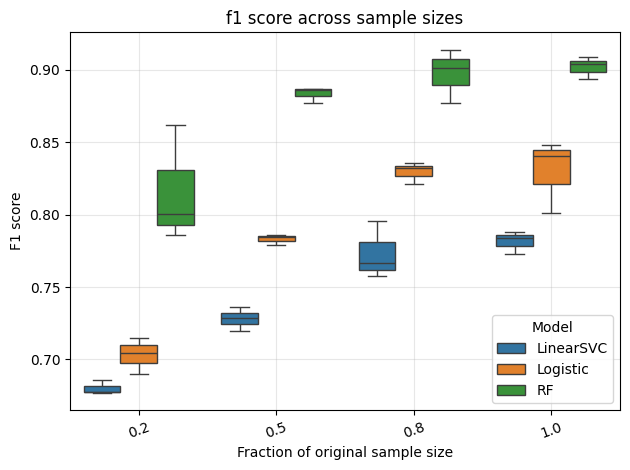

In [29]:
sns.boxplot(
    data=df,
    x="Sample size",
    y="f1 score",
    hue = "Model"
)
plt.title("f1 score across sample sizes")
plt.xlabel("Fraction of original sample size")
plt.ylabel("F1 score")
plt.tick_params(axis="x", rotation=20)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
X.shape()
pd.set_option("display.precision", 2)
X.head()
X.tail()
X.info()
X.describe()



In [ ]:

c_values = np.logspace(-3, 3, 20)
num_trees = [25, 50, 75]
sample_sizes = [0.2, 0.5, 0.8, 1.0]
random_seeds = [42, 67, 1]
pca_values = ["passthrough", PCA(10), PCA(20), PCA(50), PCA(100)]

models_tested = ["LinearSVC", "Logistic", "RF"]
possible_values = {"LinearSVC": {"Classifier__C": c_values, "pca": pca_values}, "Logistic": {"Classifier__C": c_values,"pca": pca_values}, "RF": {"Classifier__n_estimators": num_trees, "Classifier__max_depth": [None, 10, 20]}}
results = {
    "Sample size": [],
    "Model": [],
    "Seed": [],
    "Best parameters": [],
    "f1 score": []
}

warnings.filterwarnings("ignore", category=ConvergenceWarning)

def training(random_seed, results, possible_values, X, y, size):
    if size < 1:
        X, _, y, _ = train_test_split(X, y, train_size = size, random_state=random_seed)
    X_train, X_valid, y_train, y_valid = train_test_split(
        X,
        y, 
        test_size=0.2,
        stratify=y,
        random_state=random_seed
    )

    #Linear regression 
    pipe_linear = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', 'passthrough'),
        ('Classifier', LinearSVC(random_state=random_seed))
    ])
    #find optimal values for linear
    opt_linear =RandomizedSearchCV(
        pipe_linear,
        param_distributions=possible_values["LinearSVC"],
        n_iter = 10,
        cv = StratifiedKFold(n_splits=3, shuffle = True, random_state = random_seed),
        scoring = "f1_macro",
        n_jobs=-1
    )

    opt_linear.fit(X_train, y_train)
    y_pred_linear = opt_linear.predict(X_valid)

    
    f1_linear = f1_score(y_valid, y_pred_linear, average = "macro")
    print(f"Best estimator for linear with score {opt_linear.best_score_} and parameters {opt_linear.best_params_}")
    print(f"f1 score: {f1_linear}")

    pipe_logistic = Pipeline([
        ('scaler', StandardScaler()),   
        ('pca', 'passthrough'),
        ('Classifier', LogisticRegression(max_iter=5000, solver="saga", random_state=random_seed))
    ])
    #find optimal values for linear
    opt_logistic =RandomizedSearchCV(
        pipe_logistic,
        param_distributions=possible_values["Logistic"],
        n_iter = 10,
        cv = StratifiedKFold(n_splits=3, shuffle = True, random_state = random_seed),
        scoring = "f1_macro",
        n_jobs=-1
    )

    opt_logistic.fit(X_train, y_train)
    y_pred_logistic = opt_logistic.predict(X_valid)
    f1_logistic = f1_score(y_valid, y_pred_logistic, average = "macro")
    print(f"Best estimator for logistic with score {opt_logistic.best_score_} and parameters {opt_logistic.best_params_}")
    print(f"f1 score: {f1_logistic}")

    pipe_rf = Pipeline([  
        ('Classifier', RandomForestClassifier(random_state=random_seed, n_jobs = -1))
    ])
    #find optimal values for linear
    opt_rf =RandomizedSearchCV(
        pipe_rf,
        param_distributions=possible_values["RF"],
        n_iter = 10,
        cv = StratifiedKFold(n_splits=3, shuffle = True, random_state = random_seed),
        scoring = "f1_macro",
        n_jobs=-1
    ) 

    opt_rf.fit(X_train, y_train)
    y_pred_rf = opt_rf.predict(X_valid)
    f1_rf = f1_score(y_valid, y_pred_rf, average = "macro")
    print(f"Best estimator for RF with score {opt_rf.best_score_} and parameters {opt_rf.best_params_}")
    print(f"f1 score: {f1_rf}")

    results["Sample size"].extend([size, size, size])
    results["Model"].extend(["LinearSVC", "Logistic", "RF"])
    results["Seed"].extend([random_seed, random_seed, random_seed])
    results["Best parameters"].extend([opt_linear.best_params_, opt_logistic.best_params_, opt_rf.best_params_])
    results["f1 score"].extend([f1_linear, f1_logistic, f1_rf])


    return results

<class 'pandas.core.frame.DataFrame'>


In [ ]:
#Minimum disruption
results_disruption = {
    "Sample size": [],
    "Model": [],
    "Seed": [],
    "Best parameters": [],
    "f1 score": []
}


rf = RandomForestClassifier()
rf.fit(X, labels)
importance = rf.feature_importances_

threshold = np.percentile(importance, 20)
features = importance > threshold
X_new = X[:,features]

for sample_size in sample_sizes:
    for i, n in enumerate(random_seeds):
        print(f"run {i}, sample size {sample_size}")
        results_disruption = training(n, results_disruption, possible_values, X_new, labels, sample_size)   

df_disruption = pd.DataFrame(data=results_disruption)

sns.boxplot(
    data=df,
    x="Sample size",
    y="f1 score",
    hue = "Model"
)
plt.title("f1 score across sample sizes")
plt.xlabel("Fraction of original sample size")
plt.ylabel("F1 score")
plt.tick_params(axis="x", rotation=20)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

run 0, sample size 0.2
Best estimator for linear with score 0.6846533004020948 and parameters {'pca': PCA(n_components=50), 'Classifier__C': np.float64(0.3359818286283781)}
f1 score: 0.6812792514566196
Best estimator for logistic with score 0.6932138112515619 and parameters {'pca': PCA(n_components=100), 'Classifier__C': np.float64(0.07847599703514611)}
f1 score: 0.6694320401423327


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best estimator for RF with score 0.8278358813257786 and parameters {'Classifier__n_estimators': 100, 'Classifier__max_depth': 10}
f1 score: 0.8680533602831771
run 1, sample size 0.2
Best estimator for linear with score 0.6660259045412468 and parameters {'pca': PCA(n_components=50), 'Classifier__C': np.float64(112.88378916846884)}
f1 score: 0.7226090691957817
Best estimator for logistic with score 0.7072659133333422 and parameters {'pca': PCA(n_components=20), 'Classifier__C': np.float64(483.2930238571752)}
f1 score: 0.7338467183537044


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best estimator for RF with score 0.8194411905026057 and parameters {'Classifier__n_estimators': 100, 'Classifier__max_depth': 10}
f1 score: 0.8113772246730692
run 2, sample size 0.2
Best estimator for linear with score 0.6406704345083266 and parameters {'pca': PCA(n_components=50), 'Classifier__C': np.float64(112.88378916846884)}
f1 score: 0.7301348438911762
Best estimator for logistic with score 0.6974585919217824 and parameters {'pca': PCA(n_components=10), 'Classifier__C': np.float64(0.3359818286283781)}
f1 score: 0.7524198307180745


...

Best estimator for RF with score 0.8806046029013769 and parameters {'Classifier__n_estimators': 100, 'Classifier__max_depth': None}
f1 score: 0.880003724522954
run 2, sample size 0.5
Best estimator for linear with score 0.7302535579071853 and parameters {'pca': PCA(n_components=100), 'Classifier__C': np.float64(1000.0)}
f1 score: 0.7508569351484411
Best estimator for logistic with score 0.7751270410844803 and parameters {'pca': 'passthrough', 'Classifier__C': np.float64(0.018329807108324356)}
f1 score: 0.8222234347879717


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best estimator for RF with score 0.8680711007528775 and parameters {'Classifier__n_estimators': 100, 'Classifier__max_depth': None}
f1 score: 0.8803117159736765
run 0, sample size 0.8
Best estimator for linear with score 0.7529295726807964 and parameters {'pca': PCA(n_components=200), 'Classifier__C': np.float64(12.742749857031322)}
f1 score: 0.774111725317826
Best estimator for logistic with score 0.7985919255690255 and parameters {'pca': PCA(n_components=50), 'Classifier__C': np.float64(26.366508987303554)}
f1 score: 0.8236626658831321


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best estimator for RF with score 0.8961065954919897 and parameters {'Classifier__n_estimators': 100, 'Classifier__max_depth': None}
f1 score: 0.909870873659077
run 1, sample size 0.8


In [ ]:
#Find mislabeling: 
random_seed = 42
#Best model was logistic with 89 components and c=0.1
best_components = 89
best_c = 0.1

mislabled = {
    "index": [],
    "label (mislabeled)": [],
    "predicted label": []
}
def find_mislabeled(random_seed, X, y, best_n, best_c):

    mislabeled = []

    pipe_logistic = Pipeline([
        ('scaler', StandardScaler()),   
        ('pca', PCA(best_n)),
        ('Classifier', LogisticRegression(max_iter=10000, random_state=random_seed, c=best_c))
    ])

    kfold = KFold(n_splits = 5, shufflue = True, random_state= random_seed)

    wrong = np.zeros(len(x))

    for train_idx, val_idx in kfold.split(X,y):
        pipe_logistic.fit(X[train_idx], y[train_idx])
        prediction = pipe_logistic.predict(X[val_idx])

        wrong[val_idx] += (prediction != y[val_idx])

    
    for i in range(len(wrong), 0, -1):
        if wrong[i] >= 3:
            X.pop(i)
            mislabeled.append(i)
    

    return X, mislabeled

X_without, mislabled_data = find_mislabeled(n, X, labels, best_components, best_c)   

df = pd.DataFrame(data=results)
